<a href="https://colab.research.google.com/github/kurexi/ml-labs/blob/main/GaussianProcess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process
## Generate Data

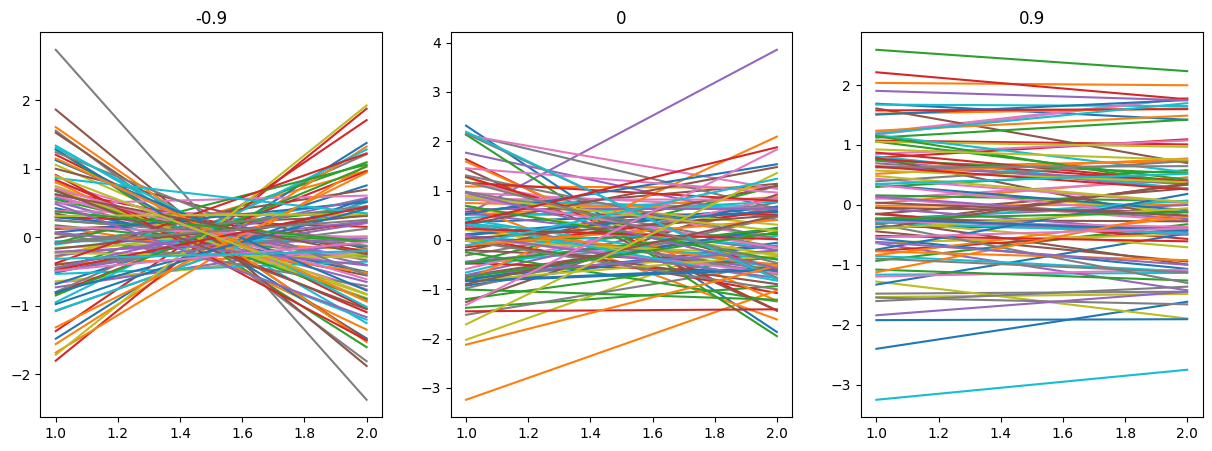

In [18]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 100

def data_gen(N, c):

  K = np.array([[1, c],
                [c, 1]])

  y = np.zeros((N, 2))

  for i in range(N):
      y[i] = np.random.multivariate_normal(np.zeros(2), K)

  return y


fig, axis = plt.subplots(1, 3, figsize=(15, 5))

cs = [-0.9, 0, 0.9]
for i in range(len(cs)):
  y = data_gen(N, cs[i])

  for pair in y:
      axis[i].plot([1, 2], pair)
      axis[i].set_title(cs[i])

plt.show()

In [19]:
def covariance_matrix(X, kernel_fun, sigma_d=1.0):
  cvx = np.zeros((len(X), len(X)))
  for i in range(len(X)):
    for j in range(len(X)):
      cvx[i, j] = kernel_fun(X[i], X[j])

  return cvx + 1e-5 * np.eye(len(X)) * sigma_d**2

def k_se(x_m, x_n, sigma=2.0, l=50.0):
  return sigma**2 * np.exp(-(x_m - x_n)**2/2/l**2)

def k_ou(x_m, x_n, sigma=2.0, l=50.0):
  return sigma**2 * np.exp(-np.abs(x_m - x_n)/l)

def k_osc(x_m, x_n, sigma=2.0, l=50.0, A=1.0, P=24.0):
  return sigma**2 * np.exp(-A * np.sin((x_m-x_n)*np.pi/P)**2 - (x_m - x_n)**2/2/l**2)

def k_lin(x_m, x_n, sigma=2.0, c=1.0):
  return sigma**2 * (x_m - c) * (x_n - c)


X = np.linspace(-N/2, N/2, N)

se = covariance_matrix(X, k_se)
ou = covariance_matrix(X, k_ou)
lin = covariance_matrix(X, k_lin)
osc = covariance_matrix(X, k_osc)

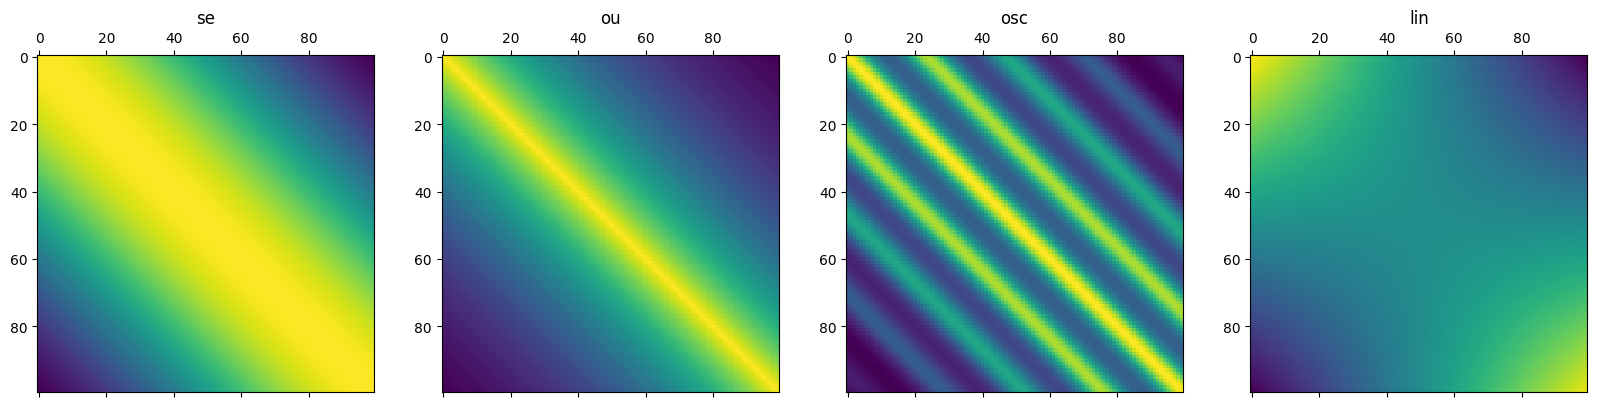

In [20]:
kernels = {'se': se, 'ou': ou, 'osc': osc, 'lin':lin}

fig, axis = plt.subplots(1, 4, figsize=(20,5))
i = 0
for title, kernel in kernels.items():
  axis[i].matshow(kernel)
  axis[i].set_title(title)
  i+=1

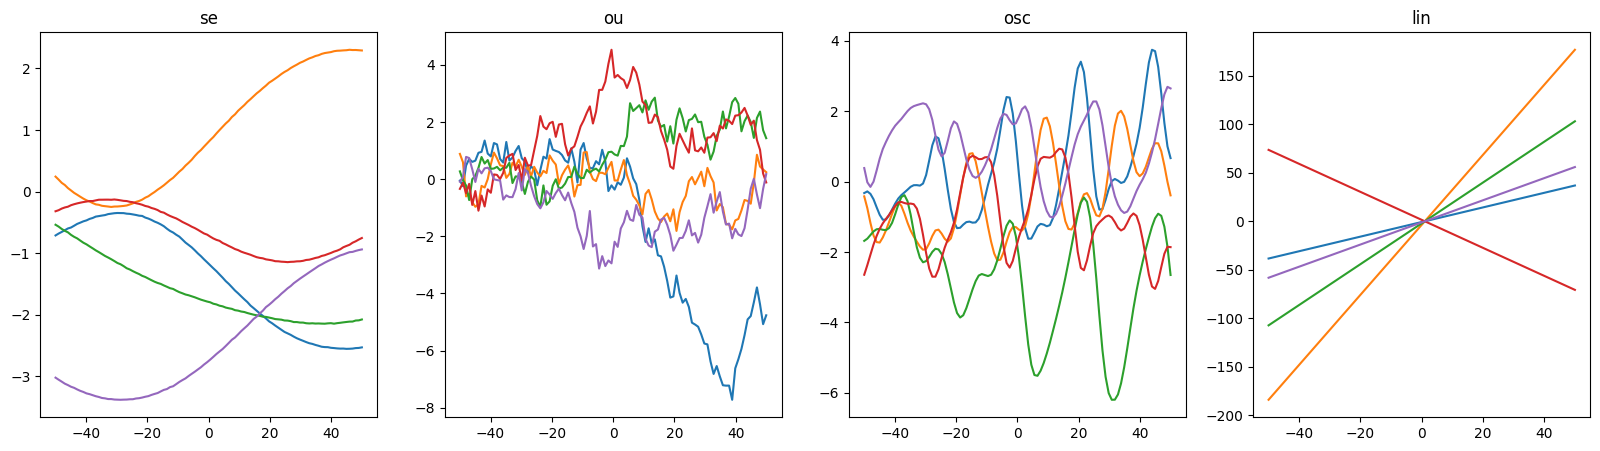

In [21]:

fig, axis = plt.subplots(1, 4, figsize=(20,5))
i = 0
for title, kernel in kernels.items():
  for _ in range(5):
    data_poits = np.random.multivariate_normal(np.zeros(N), kernel)
    axis[i].plot(X, data_poits)
    axis[i].set_title(title)
  i+=1

## Inferring plausible GP priors from samples

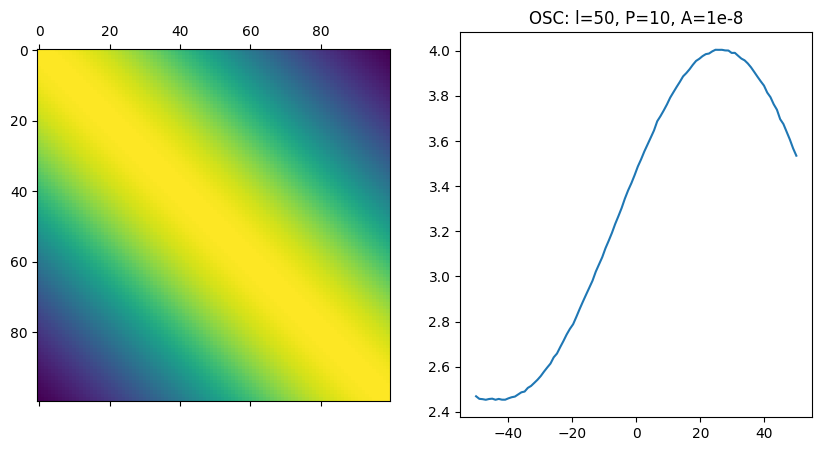

In [22]:
fig, axis = plt.subplots(1, 2, figsize=(10,5))

osc_scaled = covariance_matrix(X, lambda x,y: k_osc(x, y, l=50, P=10, A=1e-8))
axis[0].matshow(osc_scaled)
axis[1].plot(X, np.random.multivariate_normal(np.zeros(N), osc_scaled))
axis[1].set_title("OSC: l=50, P=10, A=1e-8")
plt.show()

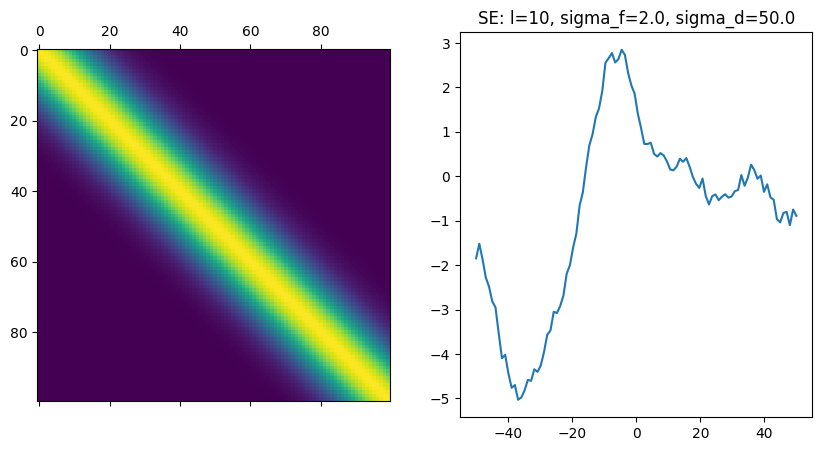

In [23]:
fig, axis = plt.subplots(1, 2, figsize=(10,5))

se_scaled = covariance_matrix(X, lambda x,y: k_se(x, y, l=10, sigma=2), sigma_d=50)
axis[0].matshow(se_scaled)
axis[1].plot(X, np.random.multivariate_normal(np.zeros(N), se_scaled))
axis[1].set_title("SE: l=10, sigma_f=2.0, sigma_d=50.0")
plt.show()

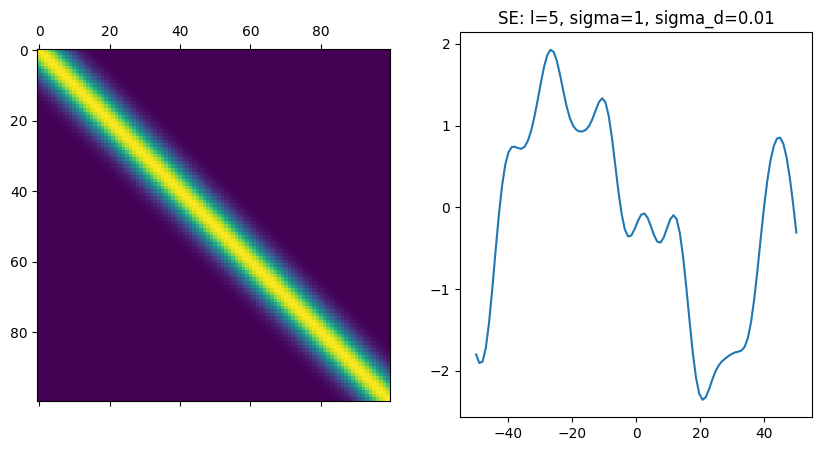

In [24]:
fig, axis = plt.subplots(1, 2, figsize=(10,5))

se_scaled2 = covariance_matrix(X, lambda x,y: k_se(x, y, l=5, sigma=1), sigma_d=0.01)
axis[0].matshow(se_scaled2)
axis[1].plot(X, np.random.multivariate_normal(np.zeros(N), se_scaled2))
axis[1].set_title("SE: l=5, sigma=1, sigma_d=0.01")
plt.show()

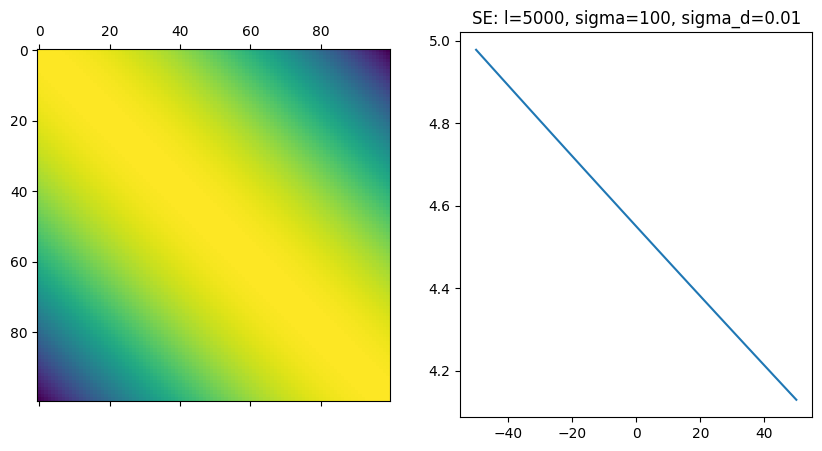

In [25]:
fig, axis = plt.subplots(1, 2, figsize=(10,5))

se_scaled3 = covariance_matrix(X, lambda x,y: k_se(x, y, l=5000, sigma=100), sigma_d=0.01)
axis[0].matshow(se_scaled3)
axis[1].plot(X, np.random.multivariate_normal(np.zeros(N), se_scaled3))
axis[1].set_title("SE: l=5000, sigma=100, sigma_d=0.01")
plt.show()

## Kernel intruduce indeuctive bias

se - NLML:-181.5850, l:3.8159, sigma_f: 2.2645, sigma_d: 1.0032
ou - NLML:70.1530, l:95.0997, sigma_f: 3.3017, sigma_d: 0.0010
lin - NLML:291.7681, l:-190.5060, sigma_f: 214.5694, sigma_d: 249.4054


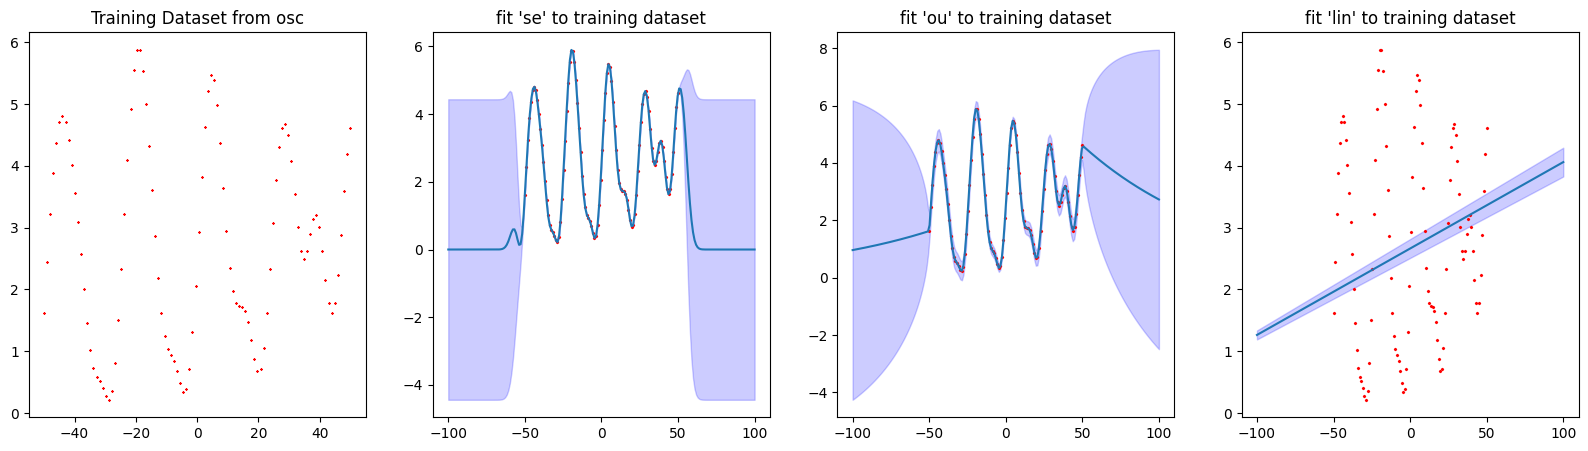

In [26]:
import scipy.optimize as opt

def negative_lml(hyperparameters, X_train, t_train, kernel_func):
  l, sigma_f, sigma_d = hyperparameters

  K_noisy = covariance_matrix(X_train, lambda m, n: kernel_func(m, n, sigma_f, l), sigma_d=sigma_d)

  sign, log_det = np.linalg.slogdet(K_noisy)
  inv_K_times_t = np.linalg.solve(K_noisy, t_train)

  data_fit = 0.5 * np.dot(t_train.T, inv_K_times_t)
  complexity_penalty = 0.5 * log_det
  constant = 0.5 * len(X_train) * np.log(2 * np.pi)

  return data_fit + complexity_penalty + constant

def cross_covariance_matrix(X1, X2, kernel_fun):
  cvx = np.zeros((len(X1), len(X2)))
  for i in range(len(X1)):
    for j in range(len(X2)):
      cvx[i, j] = kernel_fun(X1[i], X2[j])

  return cvx

fig, axis = plt.subplots(1, 4, figsize=(20,5))
sample_kernel_name = 'osc'
t_train = np.random.multivariate_normal(np.zeros(N), kernels[sample_kernel_name])
axis[0].scatter(X, t_train, c='red', s=1, marker='x')
axis[0].set_title(f"Training Dataset from {sample_kernel_name}")

X_test = np.linspace(-N, N, 2*N)

i = 0
for title, kernel_fun in {'se': k_se, 'ou': k_ou, 'lin': lambda x, y, sigma_f, l: k_lin(x, y, sigma_f, l)}.items():
  if title == 'lin':
    bounds = ((None, None), (1e-3, None), (1e-3, None)) # c is free, sigma_f and sigma_d > 0
  else:
    bounds = ((1e-3, None), (1e-3, None), (1e-3, None)) # all must be > 0
  result = opt.minimize(negative_lml, [1.0, 1.0, 1.0], args=(X, t_train, kernel_fun), bounds=bounds)
  l_op, sigma_f_op, sigma_d_op = result.x
  print(f"{title} - NLML:{result.fun:.4f}, l:{l_op:.4f}, sigma_f: {sigma_f_op:.4f}, sigma_d: {sigma_d_op:.4f}")
  learned_kernel = covariance_matrix(X, lambda x,y: kernel_fun(x, y, sigma_f_op, l_op), sigma_d=sigma_d_op)
  pure_kernel = covariance_matrix(X, lambda x,y: kernel_fun(x, y, sigma_f_op, l_op), sigma_d=0)

  inv_K_times_t = np.linalg.solve(learned_kernel, t_train)
  K_star_x = cross_covariance_matrix(X_test, X, lambda x,y: kernel_fun(x, y, sigma_f_op, l_op))
  mean_test = np.dot(K_star_x, inv_K_times_t)

  K_star_star = covariance_matrix(X_test, lambda x,y: kernel_fun(x, y, sigma_f_op, l_op), sigma_d=0)
  inv_K_times_K_x_star = np.linalg.solve(learned_kernel, K_star_x.T)
  covariance_test = K_star_star - np.dot(K_star_x, inv_K_times_K_x_star)
  std_test = np.sqrt(np.maximum(np.diag(covariance_test), 0))

  axis[i+1].fill_between(X_test, mean_test - 1.96*std_test, mean_test + 1.96*std_test, color='blue', alpha=0.2)
  axis[i+1].scatter(X, t_train, c='red', s=2, marker='x')
  axis[i+1].plot(X_test, mean_test)
  axis[i+1].set_title(f"fit '{title}' to training dataset")
  i+=1

plt.show()


## GP posteriors and confidence intervals


In [27]:
X_test_hd = np.linspace(-N/8+N/2, N/8+N/2, 2*N)
result = opt.minimize(negative_lml, [1.0, 1.0, 1.0], args=(X, t_train, k_se))
l_op, sigma_f_op, sigma_d_op = result.x
learned_kernel = covariance_matrix(X, lambda x,y: k_se(x, y, sigma_f_op, l_op), sigma_d=sigma_d_op)
pure_kernel = covariance_matrix(X, lambda x,y: k_se(x, y, sigma_f_op, l_op), sigma_d=0)

inv_K_times_t = np.linalg.solve(learned_kernel, t_train)
K_star_x = cross_covariance_matrix(X_test_hd, X, lambda x,y: k_se(x, y, sigma_f_op, l_op))
mean_test = np.dot(K_star_x, inv_K_times_t)

K_star_star = covariance_matrix(X_test_hd, lambda x,y: k_se(x, y, sigma_f_op, l_op), sigma_d=0)
inv_K_times_K_x_star = np.linalg.solve(learned_kernel, K_star_x.T)
covariance_test = K_star_star - np.dot(K_star_x, inv_K_times_K_x_star)
std_test = np.sqrt(np.maximum(np.diag(covariance_test), 0))

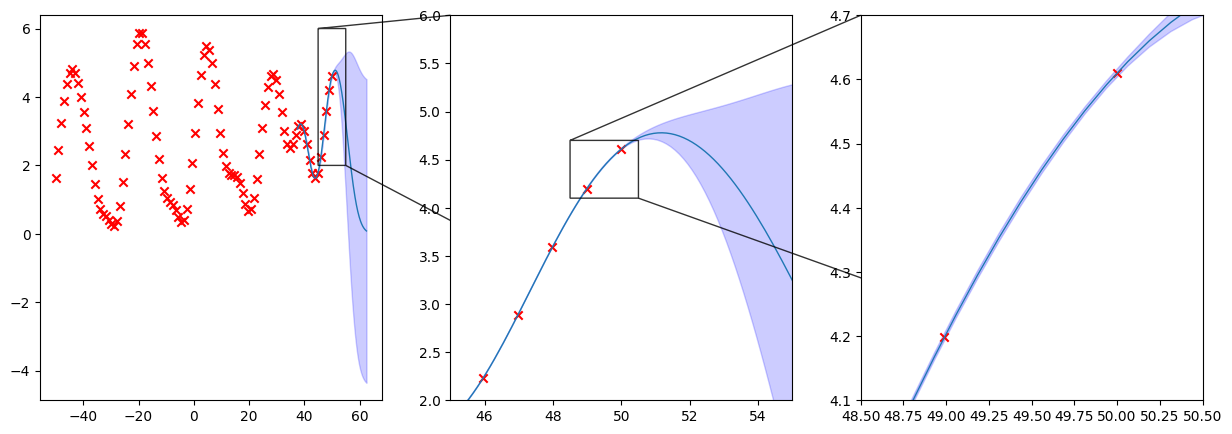

In [28]:
fig, axis = plt.subplots(1, 3, figsize=(15,5))

axis[0].fill_between(X_test_hd, mean_test - 1.96*std_test, mean_test + 1.96*std_test, color='blue', alpha=0.2)
axis[0].scatter(X, t_train, c='red', marker='x')
axis[0].plot(X_test_hd, mean_test, linewidth=1)
axis[1].fill_between(X_test_hd, mean_test - 1.96*std_test, mean_test + 1.96*std_test, color='blue', alpha=0.2)
axis[1].scatter(X, t_train, c='red', marker='x')
axis[1].plot(X_test_hd, mean_test, linewidth=1)
axis[1].set_xlim(45, 55)
axis[1].set_ylim(2, 6)
axis[0].indicate_inset_zoom(axis[1], edgecolor="black", alpha=0.8)
axis[2].fill_between(X_test_hd, mean_test - 1.96*std_test, mean_test + 1.96*std_test, color='blue', alpha=0.2)
axis[2].scatter(X, t_train, c='red', marker='x')
axis[2].plot(X_test_hd, mean_test, linewidth=1)
axis[2].set_xlim(48.5, 50.5)
axis[2].set_ylim(4.1, 4.7)
axis[1].indicate_inset_zoom(axis[2], edgecolor="black", alpha=0.8)
plt.show()

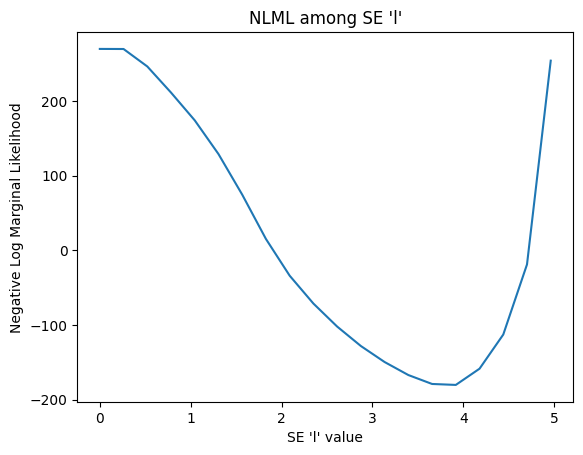

In [29]:
l_values = np.linspace(0.0001, 1.3*l_op, 20)
nlmls = []
for l_value in l_values:
  X_test = np.linspace(-N/2, N/2, N)
  nlml = negative_lml((l_value, sigma_f_op, sigma_d_op), X, t_train, k_se)
  nlmls.append(nlml)

plt.plot(l_values, nlmls)
plt.xlabel("SE 'l' value")
plt.ylabel("Negative Log Marginal Likelihood")
plt.title("NLML among SE 'l'")
plt.show()



## Bayesian optimisation

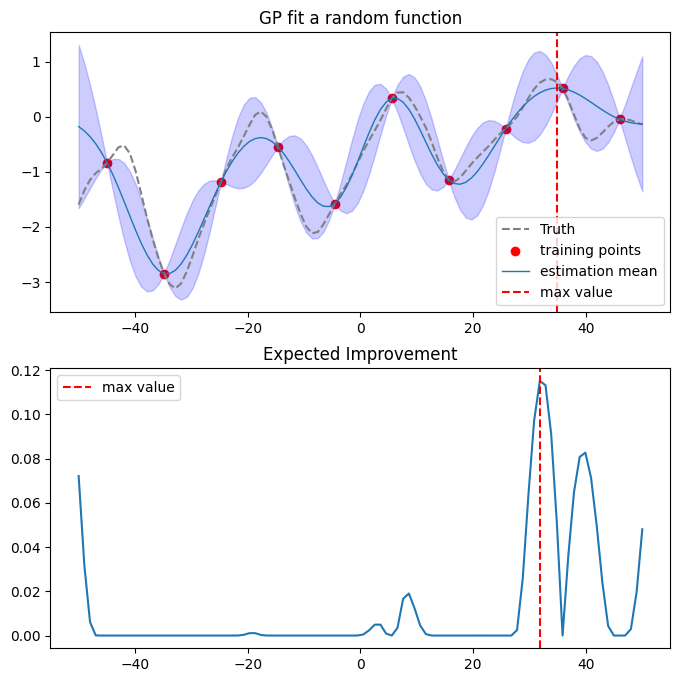

In [30]:
from scipy.stats import norm

np.random.seed(42)

def expected_improvement(mu, sigma, eta):
  ei = np.zeros_like(mu)
  mask = sigma > 0
  Z = (mu[mask]-eta)/sigma[mask]
  ei[mask] = (mu[mask] - eta) * norm.cdf(Z) + sigma[mask] * norm.pdf(Z)
  ei[~mask] = np.maximum(0, mu[~mask] - eta)
  return ei

fig, axis = plt.subplots(2, 1, figsize=(8,8))

N=100
x_test = np.linspace(-N/2, N/2, N)
truth = np.random.multivariate_normal(np.zeros(N), covariance_matrix(x_test, lambda x, y: k_osc(x, y, l=100)))
axis[0].plot(x_test, truth, linestyle='--', c='gray', label='Truth')

x_train = x_test[5::10]
t_train = truth[5::10]
axis[0].scatter(x_train, t_train, c='red', label='training points')

result = opt.minimize(negative_lml, [2, 1.0, 1.0], args=(x_train, t_train, k_se))
l_op, sigma_f_op, sigma_d_op = result.x
learned_kernel = covariance_matrix(x_train, lambda x,y: k_se(x, y, sigma_f_op, l_op), sigma_d=sigma_d_op)
pure_kernel = covariance_matrix(x_train, lambda x,y: k_se(x, y, sigma_f_op, l_op), sigma_d=0)

inv_K_times_t = np.linalg.solve(learned_kernel, t_train)
K_star_x = cross_covariance_matrix(x_test, x_train, lambda x,y: k_se(x, y, sigma_f_op, l_op))
mean_test = np.dot(K_star_x, inv_K_times_t)

K_star_star = covariance_matrix(x_test, lambda x,y: k_se(x, y, sigma_f_op, l_op), sigma_d=0)
inv_K_times_K_x_star = np.linalg.solve(learned_kernel, K_star_x.T)
covariance_test = K_star_star - np.dot(K_star_x, inv_K_times_K_x_star)
std_test = np.sqrt(np.maximum(np.diag(covariance_test), 0))

i_eta =  np.argmax(mean_test)

axis[0].fill_between(x_test, mean_test - 1.96*std_test, mean_test + 1.96*std_test, color='blue', alpha=0.2)
axis[0].plot(x_test, mean_test, linewidth=1, label='estimation mean')
axis[0].set_title('GP fit a random function')
axis[0].axvline(x=x_test[i_eta], color='red', linestyle='--', label='max value')
axis[0].legend()

eis = [expected_improvement(mean_test, std_test, mean_test[i_eta])]
axis[1].plot(x_test, eis[0])
axis[1].axvline(x=x_test[np.argmax(eis[0])], color='red', linestyle='--', label='max value')
axis[1].set_title('Expected Improvement')
axis[1].legend()

plt.show()

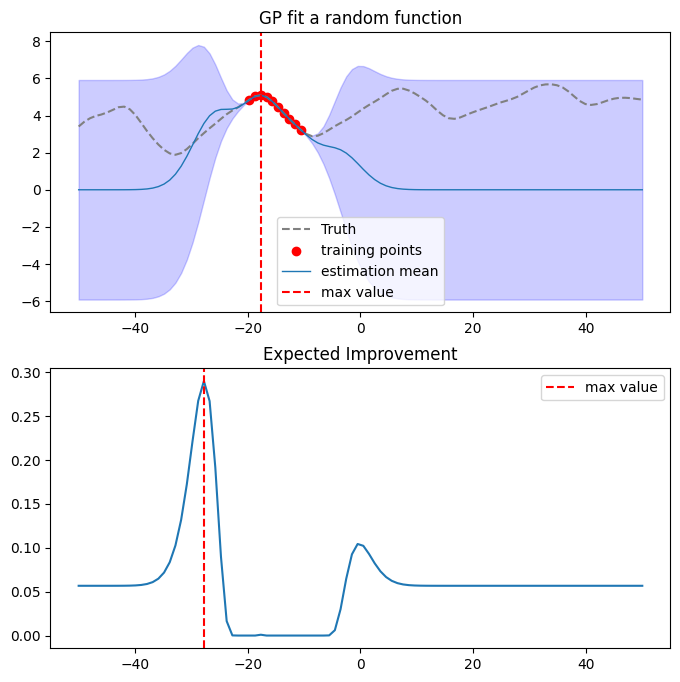

In [53]:
# Failure snario
fig, axis = plt.subplots(2, 1, figsize=(8,8))
truth2 = truth+5
axis[0].plot(x_test, truth2, linestyle='--', c='gray', label='Truth')

x_train = x_test[30:40:1]
t_train = truth2[30:40:1]
axis[0].scatter(x_train, t_train, c='red', label='training points')

result = opt.minimize(negative_lml, [2, 1.0, 1.0], args=(x_train, t_train, k_se))
l_op, sigma_f_op, sigma_d_op = result.x
learned_kernel = covariance_matrix(x_train, lambda x,y: k_se(x, y, sigma_f_op, l_op), sigma_d=sigma_d_op)
pure_kernel = covariance_matrix(x_train, lambda x,y: k_se(x, y, sigma_f_op, l_op), sigma_d=0)

inv_K_times_t = np.linalg.solve(learned_kernel, t_train)
K_star_x = cross_covariance_matrix(x_test, x_train, lambda x,y: k_se(x, y, sigma_f_op, l_op))
mean_test = np.dot(K_star_x, inv_K_times_t)

K_star_star = covariance_matrix(x_test, lambda x,y: k_se(x, y, sigma_f_op, l_op), sigma_d=0)
inv_K_times_K_x_star = np.linalg.solve(learned_kernel, K_star_x.T)
covariance_test = K_star_star - np.dot(K_star_x, inv_K_times_K_x_star)
std_test = np.sqrt(np.maximum(np.diag(covariance_test), 0))

i_eta =  np.argmax(mean_test)

axis[0].fill_between(x_test, mean_test - 1.96*std_test, mean_test + 1.96*std_test, color='blue', alpha=0.2)
axis[0].plot(x_test, mean_test, linewidth=1, label='estimation mean')
axis[0].set_title('GP fit a random function')
axis[0].axvline(x=x_test[i_eta], color='red', linestyle='--', label='max value')
axis[0].legend()

eis = [expected_improvement(mean_test, std_test, mean_test[i_eta])]
axis[1].plot(x_test, eis[0])
axis[1].axvline(x=x_test[np.argmax(eis[0])], color='red', linestyle='--', label='max value')
axis[1].set_title('Expected Improvement')
axis[1].legend()

plt.show()

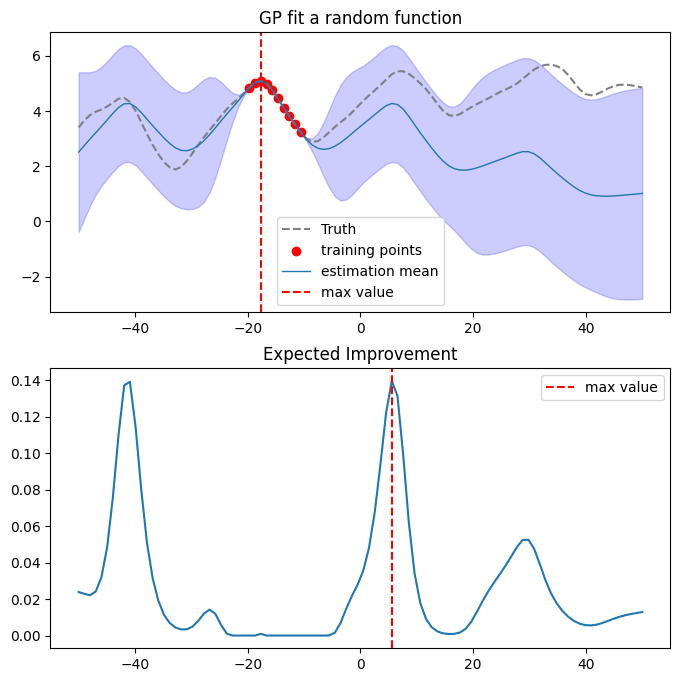

In [56]:
# Failure snario
fig, axis = plt.subplots(2, 1, figsize=(8,8))
axis[0].plot(x_test, truth2, linestyle='--', c='gray', label='Truth')

x_train = x_test[30:40:1]
t_train = truth2[30:40:1]
axis[0].scatter(x_train, t_train, c='red', label='training points')

result = opt.minimize(negative_lml, [1.0, 1.0, 1.0], args=(x_train, t_train, k_osc))
l_op, sigma_f_op, sigma_d_op = result.x
learned_kernel = covariance_matrix(x_train, lambda x,y: k_osc(x, y, sigma_f_op, l_op), sigma_d=sigma_d_op)
pure_kernel = covariance_matrix(x_train, lambda x,y: k_osc(x, y, sigma_f_op, l_op), sigma_d=0)

prior_m = 0

inv_K_times_t = np.linalg.solve(learned_kernel, t_train - prior_m)
K_star_x = cross_covariance_matrix(x_test, x_train, lambda x,y: k_osc(x, y, sigma_f_op, l_op))
mean_test = prior_m + np.dot(K_star_x, inv_K_times_t)

K_star_star = covariance_matrix(x_test, lambda x,y: k_osc(x, y, sigma_f_op, l_op), sigma_d=0)
inv_K_times_K_x_star = np.linalg.solve(learned_kernel, K_star_x.T)
covariance_test = K_star_star - np.dot(K_star_x, inv_K_times_K_x_star)
std_test = np.sqrt(np.maximum(np.diag(covariance_test), 0))

i_eta =  np.argmax(mean_test)

axis[0].fill_between(x_test, mean_test - 1.96*std_test, mean_test + 1.96*std_test, color='blue', alpha=0.2)
axis[0].plot(x_test, mean_test, linewidth=1, label='estimation mean')
axis[0].set_title('GP fit a random function')
axis[0].axvline(x=x_test[i_eta], color='red', linestyle='--', label='max value')
axis[0].legend()

eis = [expected_improvement(mean_test, std_test, mean_test[i_eta])]
axis[1].plot(x_test, eis[0])
axis[1].axvline(x=x_test[np.argmax(eis[0])], color='red', linestyle='--', label='max value')
axis[1].set_title('Expected Improvement')
axis[1].legend()

plt.show()